<a href="https://colab.research.google.com/github/1Bur1/machine-learing-g10-coures/blob/main/day23_activation_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activation Functions: ReLU, Sigmoid, Softmax

Experiment with activation functions and see how they affect model outputs.

Estimated time: 20 minutes

How to use: run top-to-bottom

## Learning objectives
- Understand activation functions (ReLU, Sigmoid, Softmax).
- Choose appropriate activation functions for different layers.
- Experiment with different activation functions.
- Short answer: Why do we need activation functions?

## 1) Setup
Imports, a fixed seed, and a small helper for plotting activations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

def quick_summary(df, name):
    print(f"{name} shape: {df.shape}")
    print(df.head())
    print()

def plot_activation(x, y, title):
    plt.figure(figsize=(5, 3))
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("activation(x)")
    plt.axhline(0, color="gray", linewidth=0.5)
    plt.axvline(0, color="gray", linewidth=0.5)
    plt.show()

print("Setup complete ✅")

Setup complete ✅


## 2) Tiny data / inputs for today's topics
We will create a small dataset and test different activations in a simple network.

In [2]:
n = 140
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
noise = np.random.normal(0, 0.4, n)
y = (x1 - 0.7 * x2 + noise > 0).astype(int)

df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "label": y
})

quick_summary(df, "df")
print("label rate:", round(df["label"].mean(), 3))
print(df.describe().T)

df shape: (140, 3)
         x1        x2  label
0  0.496714  0.227460      1
1 -0.138264  1.307143      0
2  0.647689 -1.607483      1
3  1.523030  0.184634      1
4 -0.234153  0.259883      1

label rate: 0.486
       count      mean       std       min       25%       50%       75%  \
x1     140.0 -0.084029  0.943169 -2.619745 -0.653070 -0.095047  0.479373   
x2     140.0  0.048766  1.028518 -3.241267 -0.719069  0.163453  0.662315   
label  140.0  0.485714  0.501590  0.000000  0.000000  0.000000  1.000000   

            max  
x1     2.463242  
x2     3.852731  
label  1.000000  


## 3) Main task (guided)
Train a tiny network with different activations and compare accuracy.

In [6]:
# TODO 1: choose hidden activation (e.g., 'relu', 'tanh', 'sigmoid')
hidden_activation = "sigmoid"

# TODO 2: set number of hidden units
hidden_units = 6

# TODO 3: set epochs
epochs = 30

X = df[["x1", "x2"]].values
y = df["label"].values

model = Sequential([
    Dense(hidden_units, activation=hidden_activation, input_shape=(2,)),
    Dense(hidden_units, activation=hidden_activation, input_shape=(2,)),

    Dense(hidden_units, activation=hidden_activation, input_shape=(2,)),

    Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X, y, epochs=epochs, verbose=0)

print("Final training accuracy:", round(float(history.history["accuracy"][-1]), 3))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training accuracy: 0.514


In [7]:
# TODO 1: choose hidden activation (e.g., 'relu', 'tanh', 'sigmoid')
hidden_activation = "softmax"

# TODO 2: set number of hidden units
hidden_units = 6

# TODO 3: set epochs
epochs = 30

X = df[["x1", "x2"]].values
y = df["label"].values

model = Sequential([
    Dense(hidden_units, activation=hidden_activation, input_shape=(2,)),
    Dense(hidden_units, activation=hidden_activation, input_shape=(2,)),

    Dense(hidden_units, activation=hidden_activation, input_shape=(2,)),

    Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X, y, epochs=epochs, verbose=0)

print("Final training accuracy:", round(float(history.history["accuracy"][-1]), 3))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final training accuracy: 0.514


## 4) Verify / evaluate
Plot activation curves and check prediction ranges.

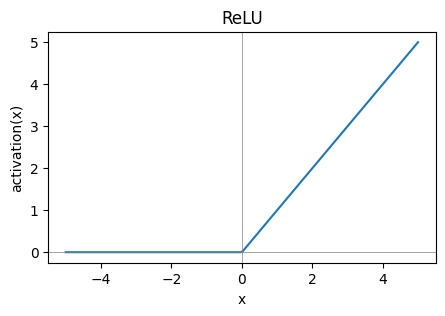

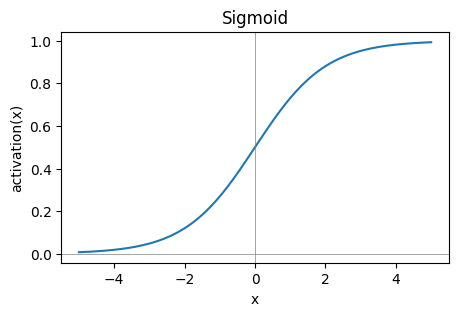

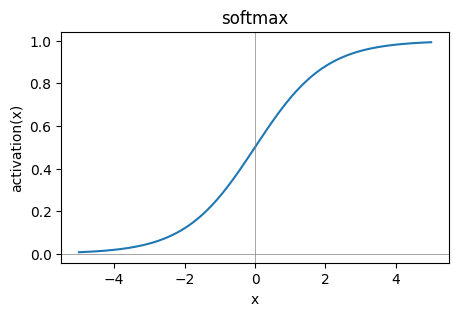

Predictions head: [0.462 0.454 0.467 0.464 0.46 ]
Interpretation: activations introduce non-linearity for richer decision boundaries.


In [8]:
x = np.linspace(-5, 5, 200)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
softmax = np.exp(x) / np.sum(np.exp(x))

plot_activation(x, relu, "ReLU")
plot_activation(x, sigmoid, "Sigmoid")
plot_activation(x, sigmoid, "softmax")


preds = model.predict(X[:5], verbose=0)
print("Predictions head:", np.round(preds.flatten(), 3))
assert np.all((preds >= 0) & (preds <= 1)), "Sigmoid outputs must be in [0, 1]."

print("Interpretation: activations introduce non-linearity for richer decision boundaries.")

## 5) Common pitfall + fix
Pitfall: using sigmoid in hidden layers can slow learning. Fix: prefer ReLU for hidden layers.

In [5]:
model_sigmoid = Sequential([
    Dense(6, activation="sigmoid", input_shape=(2,)),
    Dense(1, activation="sigmoid"),
])
model_sigmoid.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist_sigmoid = model_sigmoid.fit(X, y, epochs=8, verbose=0)

model_relu = Sequential([
    Dense(6, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid"),
])
model_relu.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist_relu = model_relu.fit(X, y, epochs=8, verbose=0)

print("Final accuracy (sigmoid hidden):", round(float(hist_sigmoid.history["accuracy"][-1]), 3))
print("Final accuracy (ReLU hidden):", round(float(hist_relu.history["accuracy"][-1]), 3))
print("Fix: use ReLU in hidden layers for faster, stable learning.")

Final accuracy (sigmoid hidden): 0.571
Final accuracy (ReLU hidden): 0.543
Fix: use ReLU in hidden layers for faster, stable learning.
